In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [4]:
df = pd.read_csv('datasets/minute maid_from_dump.csv')

In [5]:
df

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
0,0025000034824,"Minute maid, sparkling juice drink, fruit punch",Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","france, united-states",NaN,NaN,NaN,c,4.0,NaN,"Carbonated water, grape and apple juices from ...",NaN,NaN
1,0025000047244,Fruit Cooler Lemonade,Minute Maid,"beverages, carbonated-drinks, sodas, lemonade",france,NaN,NaN,NaN,e,NaN,NaN,NaN,NaN,NaN
2,0025000056017,100% Apple Juice,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...",united-states,NaN,NaN,NaN,unknown,NaN,c,NaN,NaN,NaN
3,0025000056031,100% Orange Juice,Minute Maid,"beverages-and-beverages-preparations, plant-ba...",united-states,NaN,NaN,California,e,1.0,a,"pure filtered water, concentrated orange juice...",10.0,48.9
4,0025000058073,Lemonade,Minute Maid,"beverages-and-beverages-preparations, beverage...",france,NaN,NaN,NaN,e,4.0,NaN,"Pure filtered water, high fructose corn syrup,...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
680,01070965,Minute maid,NaN,NaN,france,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
681,6975682483042,MZY Peach Juice Drink,"Minute Maid, Coca-Cola, MZY","beverages-and-beverages-preparations, plant-ba...","china, united-kingdom",NaN,NaN,NaN,e,4.0,NaN,"Water, fructose syrup, sugar, concentrated pea...",NaN,NaN
682,9416216001433,Minute Maid Pulpy,Orange,NaN,fiji,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
683,4902102060646,Apple 100%,Minute Maid,NaN,united-states,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN


# *Cleaning and Exploring Data

In [6]:
df.rename(columns={'nutriments.sugars_100g': 'sugars_100g'}, inplace=True)
df.rename(columns={'nutriments.energy-kcal_100g': 'energy_kcal_100g'}, inplace=True)

In [7]:
df.sugars_100g.unique()

array([         nan,  10.        ,  11.7       ,  10.73      ,
        11.        ,   7.91      ,   8.5       ,  13.1       ,
        12.        ,   4.17      ,  11.8644    ,  12.3       ,
        27.        ,   9.29      ,  10.42      ,   6.27      ,
         0.        ,  12.5       ,  23.75      ,  10.2       ,
        50.        ,   9.58      ,   9.16666667,  12.08333333,
        12.4       ,  11.25      ,   7.08      ,  10.17      ,
        11.86      ,  10.32      ,  11.3       ,  48.33      ,
        60.        ,  33.33      ,  40.        ,  51.11      ,
         0.83      ,  11.67      ,  24.        ,   7.08333333,
        11.34882294,   1.2       ,   1.4       ,   8.33333333,
        46.67      ,  12.08      ,   6.4       ,   9.3       ,
        10.1695    ,  13.5       ,  10.83333333,  10.42253521,
        54.        ,  11.26760563,  18.46153846,  19.23076923,
         4.16666667,  10.58201058,  19.84732824,   8.23529412,
        10.70422535,   2.17391304,   7.90960452,  10.73

In [8]:
df.energy_kcal_100g.value_counts()

energy_kcal_100g
0.000000      22
45.833333      8
0.676000       5
148.000000     5
36.000000      5
              ..
28.169014      1
6.521739       1
50.732807      1
45.197740      1
15.200000      1
Name: count, Length: 167, dtype: int64

In [9]:
df.ecoscore_grade.value_counts()

ecoscore_grade
unknown           114
not-applicable      9
c                   7
e                   5
d                   5
a                   3
Name: count, dtype: int64

In [10]:
df.columns

Index(['code', 'product_name', 'brands', 'categories_tags', 'countries_tags',
       'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade',
       'nova_group', 'ecoscore_grade', 'ingredients_text', 'sugars_100g',
       'energy_kcal_100g'],
      dtype='object')

In [11]:
df.dtypes

code                 object
product_name         object
brands               object
categories_tags      object
countries_tags       object
packaging_tags       object
stores               object
purchase_places      object
nutriscore_grade     object
nova_group          float64
ecoscore_grade       object
ingredients_text     object
sugars_100g         float64
energy_kcal_100g    float64
dtype: object

In [12]:
df.code.unique()

array(['0025000034824', '0025000047244', '0025000056017', '0025000056031',
       '0025000058073', '0025000061516', '0025000061530', '0025000063213',
       '0059600048134', '0059600060594', '0059600061904', '0059600061942',
       '0059600070159', '0059600070241', '0059600070876', '0059600070937',
       '00817141', '02505008', '02520609', '05965930', '11206388',
       '11218368', '2000000003788', '32346565', '3292090941579',
       '3292090941692', '3409664796026', '40822716', '42094418',
       '42104773', '4710018146305', '4890008200511', '54008304',
       '5449000002860', '5449000018656', '5449000034274', '5449000045614',
       '5449000045621', '5449000056313', '5449000067357', '5449000098870',
       '5449000100573', '5449000101068', '5449000111067', '5449000111104',
       '5449000136039', '5449000136060', '5449000136084', '5449000136398',
       '5449000136404', '5449000137586', '5449000142573', '5449000149596',
       '5449000156365', '5449000156389', '5449000176820', '5449

In [13]:
df.code[df.duplicated()]

Series([], Name: code, dtype: object)

In [14]:
df.isnull().sum()

code                  0
product_name         10
brands               51
categories_tags     256
countries_tags        0
packaging_tags      618
stores              659
purchase_places     646
nutriscore_grade      0
nova_group          498
ecoscore_grade      542
ingredients_text    294
sugars_100g         344
energy_kcal_100g    341
dtype: int64

In [15]:
df.packaging_tags.fillna('unknown')

0      unknown
1      unknown
2      unknown
3      unknown
4      unknown
        ...   
680    unknown
681    unknown
682    unknown
683    unknown
684    unknown
Name: packaging_tags, Length: 685, dtype: object

In [16]:
df.stores = df.stores.fillna('unknown')
df.purchase_places = df.purchase_places.fillna('unknown')
df.ecoscore_grade = df.ecoscore_grade .fillna('unknown')
df.ingredients_text = df.ingredients_text.fillna('unknown')
df.categories_tags = df.categories_tags.fillna('unknown')
df.brands = df.brands.fillna('unknown')
df.product_name = df.product_name.fillna('unknown')
df.packaging_tags = df.packaging_tags.fillna('unknown')

In [17]:
df.isnull().sum()

code                  0
product_name          0
brands                0
categories_tags       0
countries_tags        0
packaging_tags        0
stores                0
purchase_places       0
nutriscore_grade      0
nova_group          498
ecoscore_grade        0
ingredients_text      0
sugars_100g         344
energy_kcal_100g    341
dtype: int64

In [18]:
df.countries_tags.unique()

array(['france, united-states', 'france', 'united-states',
       'saint-pierre-and-miquelon', 'canada, france', 'canada',
       'france, martinique, switzerland', 'belgium, france, luxembourg',
       'taiwan', 'hong-kong', 'belgium, france', 'belgium',
       'belgium, france, martinique, switzerland', 'france, spain',
       'belgium, france, world', 'united-kingdom', 'spain', 'thailand',
       'india', 'france, luxembourg', 'belgium, france, germany',
       'belgium, france, switzerland', 'belgium, france, reunion',
       'france, spain, united-states', 'canada, switzerland',
       'martinique', 'switzerland', 'france, world', 'germany',
       'belgium, world', 'singapore', 'france, united-states, world',
       'senegal', 'united-states, world', 'mexico', 'canada, germany',
       'ireland', 'aruba', 'puerto-rico', 'luxembourg', 'kenya',
       'jamaica', 'philippines', 'barbados', 'ethiopia', 'suriname',
       'malaysia', 'mayotte', 'trinidad-and-tobago', 'norway', 'japan'

In [19]:
df_clean = df.countries_tags.str.split(',').explode('countries_tags')
df_clean = df_clean.str.strip()
df_clean

0              france
1       united-states
2              france
3       united-states
4       united-states
            ...      
752             china
753    united-kingdom
754              fiji
755     united-states
756             japan
Name: countries_tags, Length: 757, dtype: object

In [20]:
df_clean.value_counts()

countries_tags
united-states                          360
france                                 152
canada                                  68
belgium                                 31
philippines                             16
world                                   16
spain                                   13
india                                   13
ireland                                 11
germany                                  8
japan                                    7
thailand                                 7
switzerland                              5
luxembourg                               5
singapore                                4
martinique                               4
netherlands                              4
hong-kong                                3
united-kingdom                           3
china                                    2
kenya                                    2
malaysia                                 2
virgin-islands-of-the-united-states    

In [21]:
df_clean.nunique()

43

# Stores
## Insights

* Extremely High Missing Data: The unknown category heavily dominates with 659 entries (~96% of the dataset), showing store information is rarely populated.
* Top Identified Retailers: Among specified stores, Dollarama leads with only 4 entries, followed by  Delhaize  and Magasins U with  2 entries  each.
* Multi-Label / Comma-Separated Entries: Several records combine multiple stores into single strings (e.g., Supermarket,SM,7-Eleven and Walmart,Real Canadian Superstore), requiring splitting/unnesting.
* High Cardinality & Generic Labels: Most identified stores appear only once, mixing actual retail chains (Walmart, Auchan, Carrefour City), fast food chains (McDonald's, Burger King), and vague non-brand terms (Supermarket, Distributeur).

# Purchase Places
## Insights
Overwhelming Missing Data: The unknown category completely dominates with 646 entries (over 94% of the dataset), indicating that purchase location is rarely recorded.

Top Identified Location: Among the few specified places, Calgary, Alberta, Canada leads with only 8 entries, followed by France with 6 entries.

Inconsistent Granularity: The data mixes different geographical levels—some entries are countries (e.g., France, United States, Belgium), some are states/regions (e.g., California, Pennsylvania), and others are full City, State, Country strings (e.g., Kharagpur, West Bengal, India).

Extreme Long Tail & Language Inconsistency: Almost all valid locations appear only 1 or 2 times, with localized spellings present (e.g., Belgique, Charleroi, Madrid, España), requiring geographical standardisation and entity extraction.

# Ingredients Data
## Insights

Massive Uninformative/Missing Data: Placeholders dominate the column, led by unknown (294 entries) and undefined (175 entries), totaling 469 uninformative rows (~68% of the dataset).

Extreme Cardinality & Uniqueness: Among valid entries, the text is highly fragmented across 208 unique ingredient lists, with nearly every product having a distinct, single-instance (count = 1) string.

Prevalence of Concentrates & Sweeteners: Common identified ingredients heavily feature juice concentrates (orange, apple, pear), added sweeteners (high fructose corn syrup, sugar, fructose syrup), and water bases.

Multilingual & Noise Presence: The column contains multiple languages (e.g., French: Jus de pomme à base de concentré) and OCR/formatting noise (e.g., abuus:naunanAry thadu...), requiring NLP cleaning and standardisation.

In [96]:
df.ingredients_text.value_counts()

ingredients_text
unknown                                                                                                                                                                                                                                                                                                                                                                                                           294
undefined                                                                                                                                                                                                                                                                                                                                                                                                         175
100% orange juice from concentrate contains pure filtered water, premium concentrated orange juice.                                                                        

# Top 5 Countries by Average Energy (kcal)

## Insights :

Jamaica leads the chart with the highest average energy intake at ~240 kcal.

Barbados (~180 kcal) and Romania (~178 kcal) follow closely in second and third place.

Trinidad and Tobago ranks fourth with an average of 150 kcal.

Luxembourg rounds out the top five at the lowest level (~122 kcal), roughly half of Jamaica's value.

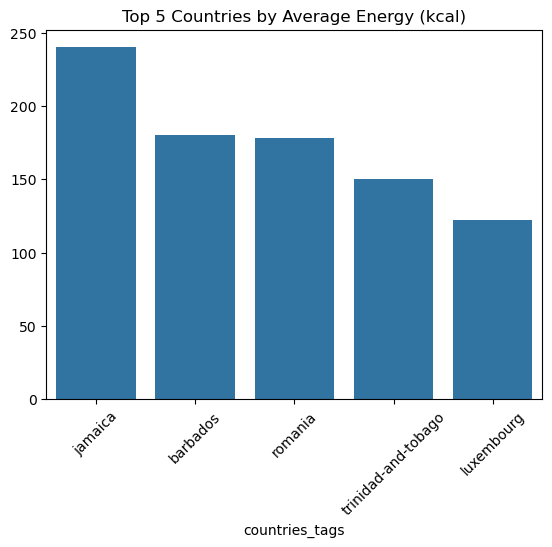

In [22]:
top5 = df.groupby('countries_tags')['energy_kcal_100g'].mean().nlargest(5)

sns.barplot(x=top5.index, y=top5.values)
plt.xticks(rotation=45)
plt.title('Top 5 Countries by Average Energy (kcal)')
plt.show()

# Top 5 Countries by Average Suger Content

## Insights

Jamaica ranks highest with an average sugar content of 60g per 100g.

Barbados (~44g) and Trinidad and Tobago (~38g) follow in second and third place.

Luxembourg places fourth with an average of 26g per 100g.

United States has the lowest value among the top five at approximately 13g per 100g (less than a quarter of Jamaica's content).

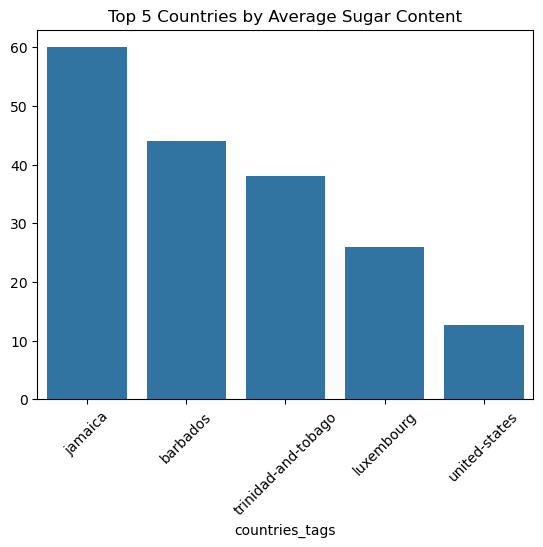

In [23]:
top5 = df.groupby('countries_tags')['sugars_100g'].mean().nlargest(5)

sns.barplot(x=top5.index, y=top5.values)
plt.xticks(rotation=45)
plt.title('Top 5 Countries by Average Sugar Content')
plt.show()

# Top 10 Product Distribution Across Countries

## Insights 

United States heavily dominates the dataset with 360 entries, accounting for more than double the second-place country.

France (152) and Canada (68) form the primary mid-tier, showing a steep drop-off after North America and Western Europe's top entries.

Belgium (31), Philippines (16), and World (16) trail significantly, each contributing a fraction of the top volume.

Long Tail Distribution: The remaining countries in the top 10 (Spain, India, Ireland, Germany) taper off sharply into single-to-low-double digits ($\le$13 entries).

countries_tags
united-states                          360
france                                 152
canada                                  68
belgium                                 31
philippines                             16
world                                   16
spain                                   13
india                                   13
ireland                                 11
germany                                  8
japan                                    7
thailand                                 7
switzerland                              5
luxembourg                               5
singapore                                4
martinique                               4
netherlands                              4
hong-kong                                3
united-kingdom                           3
china                                    2
kenya                                    2
malaysia                                 2
virgin-islands-of-the-united-states    

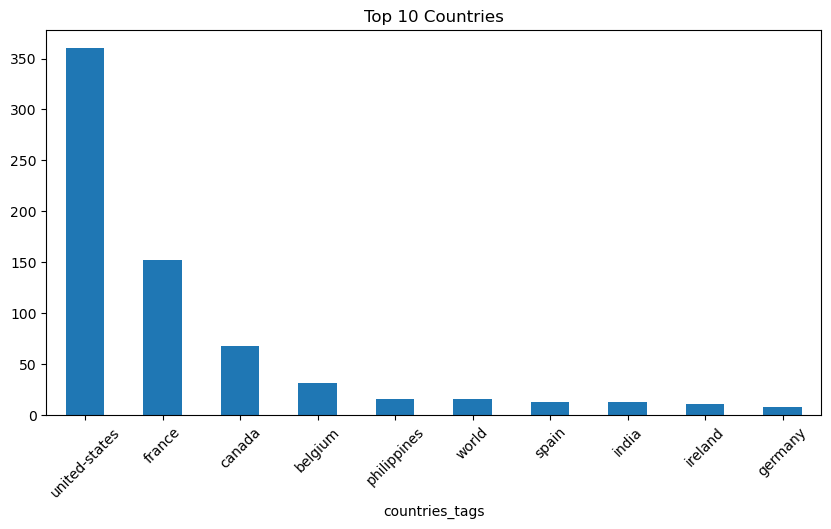

In [24]:

df_clean = df['countries_tags'].str.split(',').explode().str.strip()
countries_graph = df_clean.value_counts()
display(countries_graph)
countries_graph.head(10).plot(kind='bar', figsize=(10,5), title='Top 10 Countries')

plt.xticks(rotation=45)
plt.show()

In [25]:
df_clean

0              france
0       united-states
1              france
2       united-states
3       united-states
            ...      
681             china
681    united-kingdom
682              fiji
683     united-states
684             japan
Name: countries_tags, Length: 757, dtype: object

In [26]:
df_cleanpt = df.packaging_tags.str.split(',').explode('packaging_tags')
df_cleanpt = df_cleanpt.str.strip()
df_cleanpt

0      unknown
1      unknown
2      unknown
3      unknown
4      unknown
        ...   
726    unknown
727    unknown
728    unknown
729    unknown
730    unknown
Name: packaging_tags, Length: 731, dtype: object

In [27]:
df_cleanpt.value_counts()

packaging_tags
unknown                          618
bottle                            18
can                               14
drink-can                         12
plastic                           12
tetra-pak                          6
cardboard                          5
brick                              5
metal                              4
tetra-brik-aseptic                 4
multilayer-composite               3
tetra-brik                         2
glass                              2
aluminium                          2
recyclable-metals                  2
pet-bottle                         2
plastic-bottle                     2
container                          1
bouteille-en-verre                 1
tetra-pac                          1
paper-based-carton                 1
bottle-or-vial                     1
conserve                           1
gold-bricks                        1
1-canette-en-metal-a-recycler      1
brique                             1
th:ขวดพลาสติก          

In [28]:
df_cleanpt.nunique()

35

# Packaging Tags / Country

## Insights

Graph for Packaging tags with 618 are the unknown values which we drop for better understanding of data.

Heavy Missing/Unlabeled Data: The unknown category completely dominates with 618 entries, indicating the vast majority of records lack specific packaging information.

Top Identified Types: Among labeled items, bottle (18), can (14), drink-can (12), and plastic (12) are the most common packaging materials.

Format Fragmentation: There are redundant and overlapping labels that represent similar materials (e.g., bottle, pet-bottle, plastic-bottle, bouteille-en-verre, and bottle-or-vial).

High Cardinality / Long Tail: Most specific packaging types (e.g., tetra-pac, paper-based-carton, conserve, box) appear with minimal frequency ($\le 5$ occurrences or single instances).

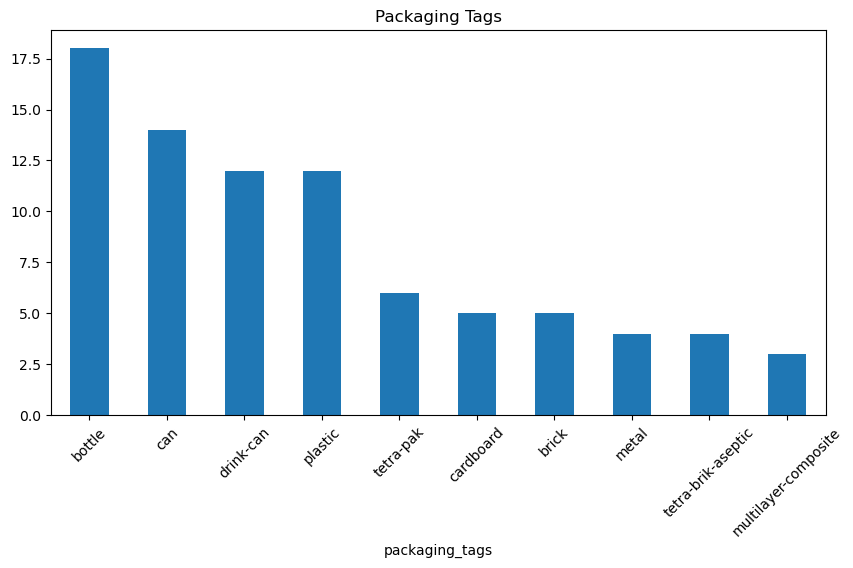

In [29]:
packaging_graph = df_cleanpt.value_counts().drop('unknown', errors='ignore')

packaging_graph.head(10).plot(kind='bar', figsize=(10,5), title='Packaging Tags')

plt.xticks(rotation=45)
plt.show()

In [30]:
df.nutriscore_grade.unique()

array(['c', 'e', 'unknown', 'd', 'b'], dtype=object)

In [31]:
df.nutriscore_grade.value_counts()

nutriscore_grade
unknown    316
e          144
b          102
c           83
d           40
Name: count, dtype: int64

# Nutriscore Grade Distribution

## Insights

 We Drop unknown ( It contains 316 count) column for the better understanding of data 

 Dominant Missingness: With 316 unknown entries, unclassified data accounts for nearly 46% of the entire dataset ($\approx 685$ total rows), outnumbering any single recorded grade.
 
 Grade 'e' Leads Known Values: Among classified products, Grade e is the most frequent (~144 items), followed by b (~102 items) and c (~83 items).
 
 Grade 'd' is Least Represented: Grade d has the lowest count among the visible grades at approximately 40 items.
 
 Completely Missing Grade 'a': The highest nutritional quality category (Grade a) is entirely absent from the distribution.

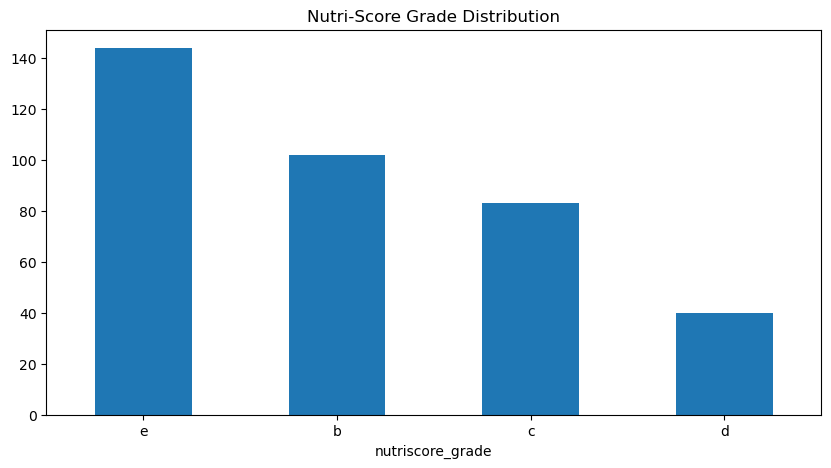

In [32]:
df.nutriscore_grade.value_counts().drop('unknown', errors='ignore').plot(
    kind='bar',
    figsize=(10,5),
    title='Nutri-Score Grade Distribution'
)

plt.xticks(rotation=0)
plt.show()

In [33]:
df.columns

Index(['code', 'product_name', 'brands', 'categories_tags', 'countries_tags',
       'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade',
       'nova_group', 'ecoscore_grade', 'ingredients_text', 'sugars_100g',
       'energy_kcal_100g'],
      dtype='object')

In [34]:
df.nova_group

0      4.0
1      NaN
2      NaN
3      1.0
4      4.0
      ... 
680    NaN
681    4.0
682    NaN
683    NaN
684    NaN
Name: nova_group, Length: 685, dtype: float64

In [35]:
df.nova_group.unique()

array([ 4., nan,  1.,  3.])

In [36]:
df['nova_group'].isna().sum()

np.int64(498)

# Nova Group

## Insights

High Proportion of Missing Data: A massive 498 values are missing (NaN), accounting for approximately 72.7% of the entire dataset (187 non-null out of 685 total entries).

Ultra-Processed Foods Dominate (Group 4.0): Among known records, Group 4.0 (ultra-processed food) is the largest category by far with 133 items (~71.1% of valid data).

Unprocessed/Minimally Processed (Group 1.0): The second-largest category is Group 1.0 with 50 items (~26.7% of valid data).

Sparse Group 3.0 & Missing Group 2.0: Group 3.0 (processed foods) is rare with only 4 items (~2.1%), while Group 2.0 (processed culinary ingredients) is completely absent.

In [37]:
df.nova_group.value_counts()

nova_group
4.0    133
1.0     50
3.0      4
Name: count, dtype: int64

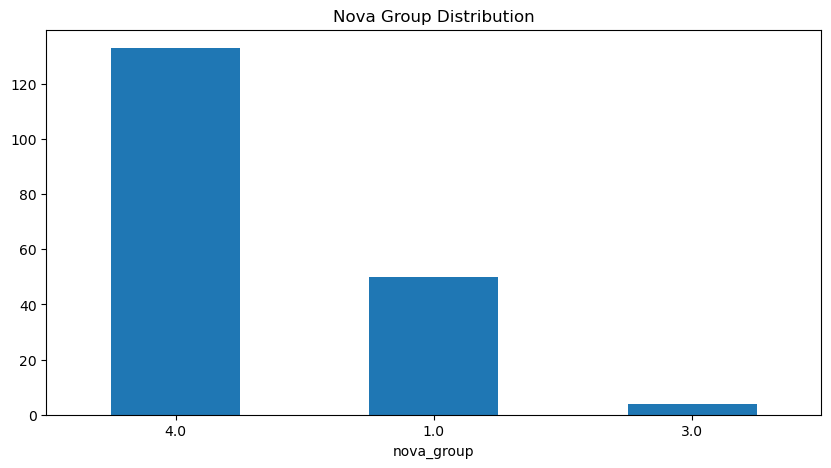

In [38]:
NovaGroup = df.nova_group.value_counts().plot(
    kind='bar',
    figsize=(10,5),
    title='Nova Group Distribution'
)

plt.xticks(rotation=0)
plt.show()

In [39]:
top_10_countries = df['countries_tags'].value_counts().nlargest(10).index
df_top10 = df[df['countries_tags'].isin(top_10_countries)]

In [40]:
top_10_countries

Index(['united-states', 'france', 'canada', 'philippines', 'belgium, france',
       'india', 'ireland', 'united-states, world', 'belgium',
       'france, united-states'],
      dtype='object', name='countries_tags')

In [41]:
df.stores.unique()

array(['unknown', 'Jewel Osco', "McDonald's", 'Delhaize', 'Supermarket',
       'Magasins U', 'Noz', 'Distributeur', 'Carrefour City', 'colruyt',
       'Aéroport de Charleroi-Bruxelles-Sud', 'Eurodisney', 'Dollarama',
       'Walmart,Real Canadian Superstore', 'auchan', 'Urban Fare',
       'Walmart', 'Real Canadian Superstore', 'Store,Supermarkets',
       'Supermarket,SM,7-Eleven', 'Burger King', 'Maxi'], dtype=object)

In [42]:
df.stores.nunique()

22

In [43]:
df['stores'].isna().sum()

np.int64(0)

In [44]:
df.purchase_places.unique()

array(['unknown', 'California', 'Saint Pierre et Miquelon',
       'Chicago,Illinois,USA', 'Pennsylvania', 'Paris,France', 'Taipei',
       'Hong Kong', 'Belgium', 'Courrières,France', 'Lyon,France',
       'Marseille,France', 'Madrid,España', 'France',
       'Belgique,Charleroi', 'Kharagpur,West Bengal,India', 'rochefort',
       'United States', 'Calgary,Alberta,Canada', 'Singapore', 'India',
       'Philippines', 'Quebec Canada'], dtype=object)

In [45]:
df.purchase_places.nunique()

23

In [46]:
usa = df[df['countries_tags'] == 'en:united-states']

In [47]:
df['countries_tags'].value_counts().head(20)


countries_tags
united-states            341
france                   107
canada                    59
philippines               16
belgium, france           15
india                     13
ireland                   11
united-states, world       8
belgium                    8
france, united-states      8
japan                      7
thailand                   7
spain                      7
france, spain              5
canada, germany            4
canada, france             4
singapore                  4
netherlands                4
hong-kong                  3
world                      3
Name: count, dtype: int64

# USA Country Analysis


In [48]:
usa = df[df['countries_tags'].str.contains("united-states")]
usa

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,sugars_100g,energy_kcal_100g
0,0025000034824,"Minute maid, sparkling juice drink, fruit punch",Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","france, united-states",unknown,unknown,unknown,c,4.0,unknown,"Carbonated water, grape and apple juices from ...",NaN,NaN
2,0025000056017,100% Apple Juice,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...",united-states,unknown,unknown,unknown,unknown,NaN,c,unknown,NaN,NaN
3,0025000056031,100% Orange Juice,Minute Maid,"beverages-and-beverages-preparations, plant-ba...",united-states,unknown,unknown,California,e,1.0,a,"pure filtered water, concentrated orange juice...",10.0,48.9
5,0025000061516,100% apple juice,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","france, united-states",unknown,unknown,unknown,e,NaN,unknown,"CONTAINS PURE FILTERED WATER, CONCENTRATED APP...",NaN,NaN
6,0025000061530,100% ORANGE JUICE,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...",united-states,pet-bottle,unknown,unknown,e,1.0,unknown,"pure filtered water, concentrated orange juice...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671,4902102067041,アロエ & 白ぶどう,Minute Maid,unknown,united-states,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
673,4902102160407,SMOOTHIE PROTEIN ストロベリー,Minute Maid,unknown,united-states,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
674,4902102160438,SMOOTHIE PROTEIN,Minute Maid,unknown,united-states,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
677,4902102084642,朝バナナ (Morning Banana),Minute Maid,unknown,united-states,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN


# Packaging Tags Distribution in the USA

In [49]:
usap = usa.copy()

In [50]:
usap.packaging_tags.value_counts()

packaging_tags
unknown                   353
pet-bottle                  1
box, card, pasteurized      1
conserve                    1
plastic-bottle              1
tetra-pac                   1
container                   1
tetra-pak                   1
bottle                      1
Name: count, dtype: int64

In [51]:
usap['packaging_tags'] = usap['packaging_tags'].str.split(',') 
usap = usap.explode("packaging_tags")
usap['packaging_tags'] = usap['packaging_tags'].str.strip()
usap.packaging_tags.value_counts()

packaging_tags
unknown           353
pet-bottle          1
box                 1
card                1
pasteurized         1
conserve            1
plastic-bottle      1
tetra-pac           1
container           1
tetra-pak           1
bottle              1
Name: count, dtype: int64

In [52]:
tag_mapping = {
    # can
    'drink-can': 'can',
    '1-canette-en-metal-a-recycler': 'can',
    'conserve': 'can',

    # bottle
    'bouteille-verre': 'bottle',
    'bouteille-consignee': 'bottle',
    'bouteille-en-verre': 'bottle',

    # brick
    'brique': 'brick',

    # metal
    'aluminium': 'metal',
    'recyclable-metals': 'metal',

    # tetra-pak
    'tetra-brik': 'tetra-pak',
    'tetra-brik-aseptic': 'tetra-pak',
}

usap['packaging_tags'] = usap['packaging_tags'].replace(tag_mapping)

usap.packaging_tags.value_counts()

packaging_tags
unknown           353
pet-bottle          1
box                 1
card                1
pasteurized         1
can                 1
plastic-bottle      1
tetra-pac           1
container           1
tetra-pak           1
bottle              1
Name: count, dtype: int64

# USA packaging tags

## Insights 

353 are the unknown value in the packging tags for the USA country

Severe Metadata Absence: At 97.2% unknown tags, packaging data is almost entirely untracked, showing a fragmented set of 1-off counts for PET, cans, and cartons without any unified trend.

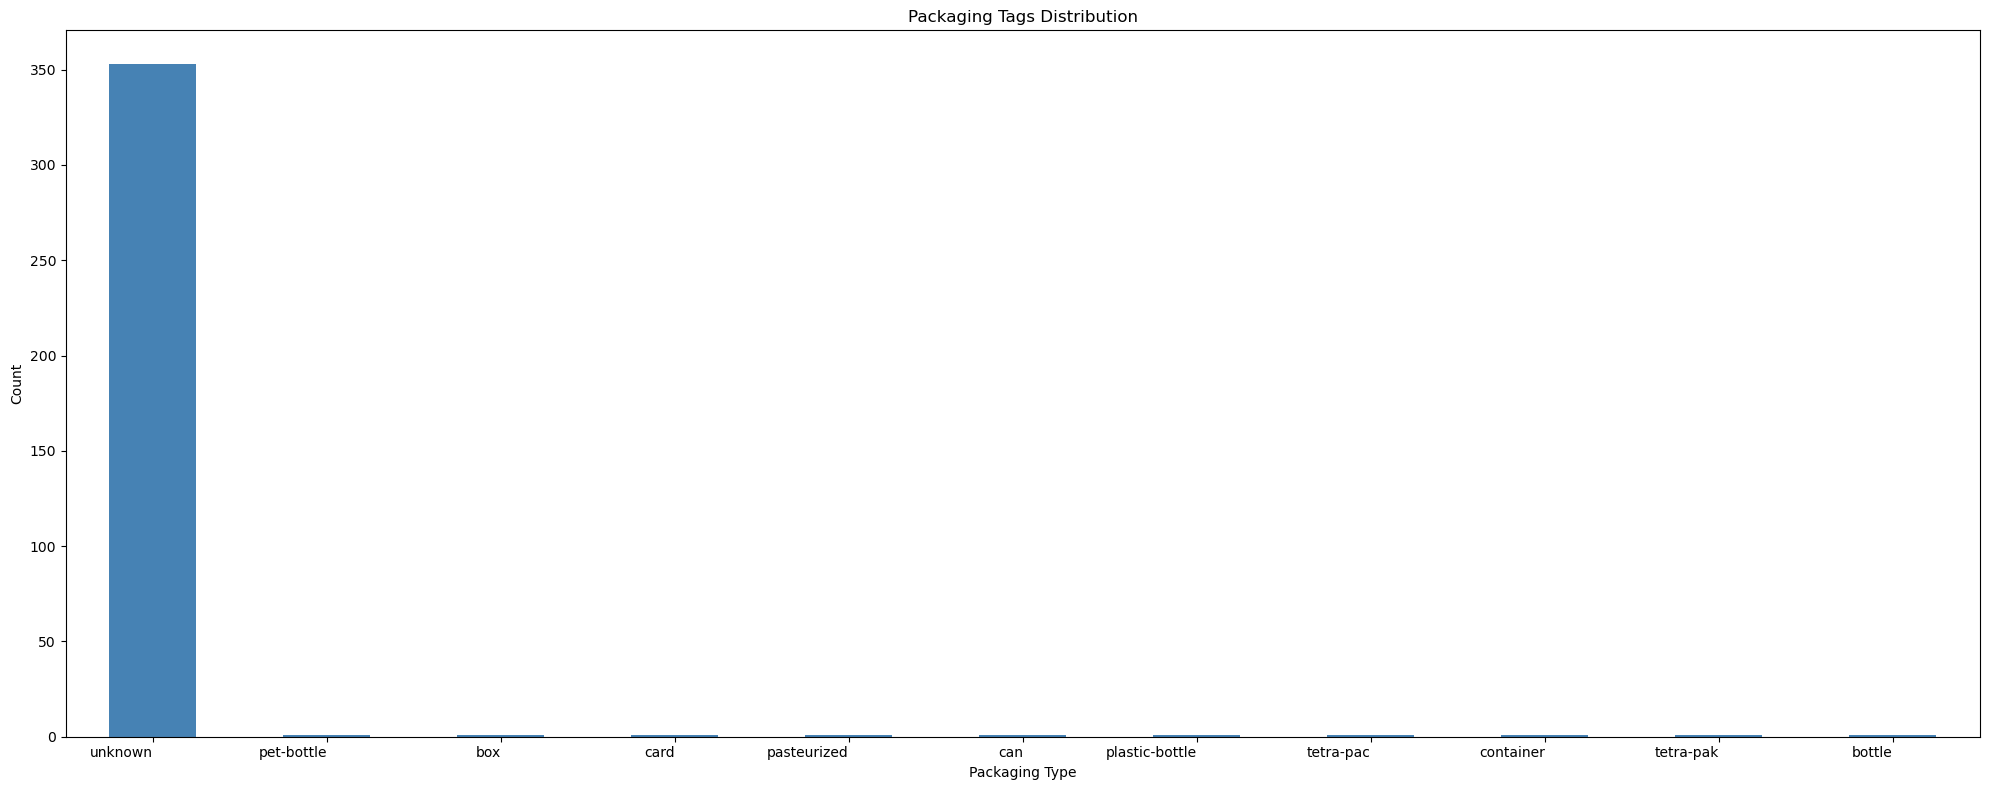

In [53]:
pcounts = usap.packaging_tags.value_counts()

plt.figure(figsize=(20, 8))
pcounts.plot(kind='bar', color='steelblue')
plt.title('Packaging Tags Distribution')
plt.xlabel('Packaging Type')
plt.ylabel('Count')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

# USA Nutri-Score Distribution

## insights

High Missing Data Filtered Out: Removing the 119 unknown entries left a clean subset of 244 labeled items for analysis.

Top Nutritional Grades ('b' & 'e'): Grade b (94) and Grade e (88) dominate the filtered data, together accounting for nearly 75% of all classified products.

Moderate to Low Representation ('c' & 'd'): Grade c holds a moderate share with 48 items, while Grade d is the least represented with only 14 items.

Absence of Grade 'a': Similar to the broader dataset, the highest nutritional tier (Grade a) is completely missing.

Polarized Quality Distribution: Nutri-Score is split between high-tier Grade B (38.5%) and low-tier Grade E (36.1%), with very little middle ground (Grade D is just 5.7%).

In [54]:
usapp = usa.copy()

In [55]:
usapp.nutriscore_grade.value_counts()

nutriscore_grade
unknown    119
b           94
e           88
c           48
d           12
Name: count, dtype: int64

In [56]:
usapp = usap[usap.nutriscore_grade != 'unknown']
usapp.nutriscore_grade.value_counts()

nutriscore_grade
b    94
e    88
c    48
d    14
Name: count, dtype: int64

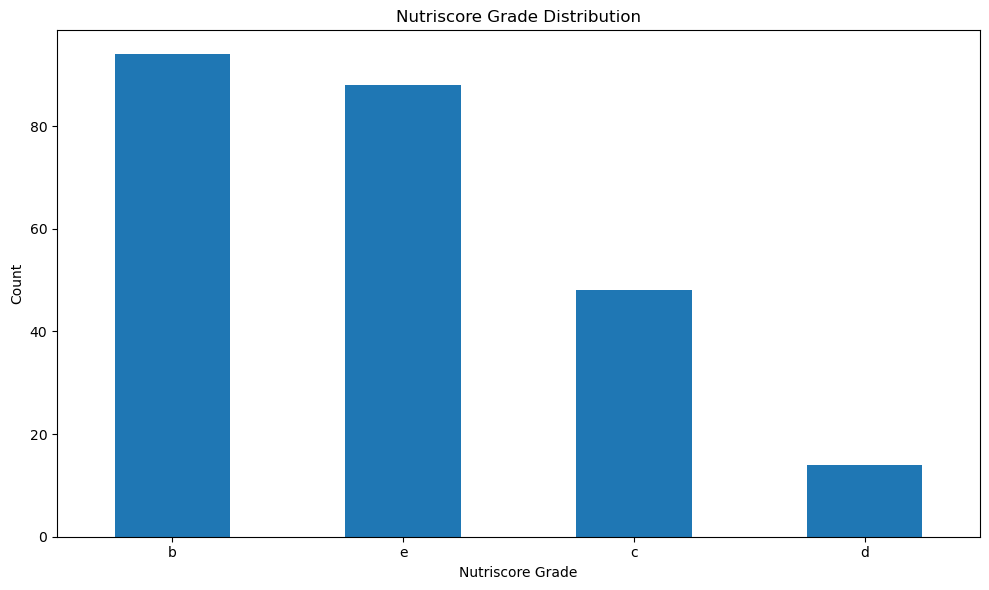

In [57]:
ncounts = usapp.nutriscore_grade.value_counts()

plt.figure(figsize=(10, 6))
ncounts.plot(kind='bar')
plt.title('Nutriscore Grade Distribution')
plt.xlabel('Nutriscore Grade')
plt.ylabel('Count')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

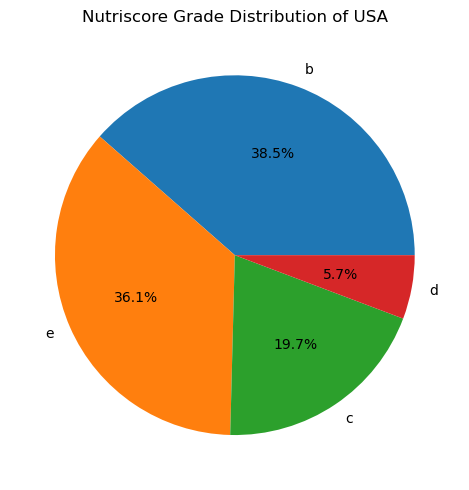

In [58]:
plt.figure(figsize=(5,5))
ncounts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Nutriscore Grade Distribution of USA')
plt.ylabel('')
plt.tight_layout()
plt.show()

# USA Nova group Analysis

## Insights

Dominance of Ultra-Processed Foods (Group 4.0): Ultra-processed items account for 71 entries (~81.6%) of the 87 total recorded values in this subset.

Unprocessed / Minimally Processed (Group 1.0): Only 16 items (~18.4%) belong to Group 1.0, representing less than a quarter of the ultra-processed volume.

Complete Absence of Groups 2.0 & 3.0: Neither processed culinary ingredients (Group 2.0) nor standard processed foods (Group 3.0) are present in this filtered distribution.



In [59]:
usappp = usa.copy()

In [60]:
usappp.nova_group.value_counts()

nova_group
4.0    71
1.0    16
Name: count, dtype: int64

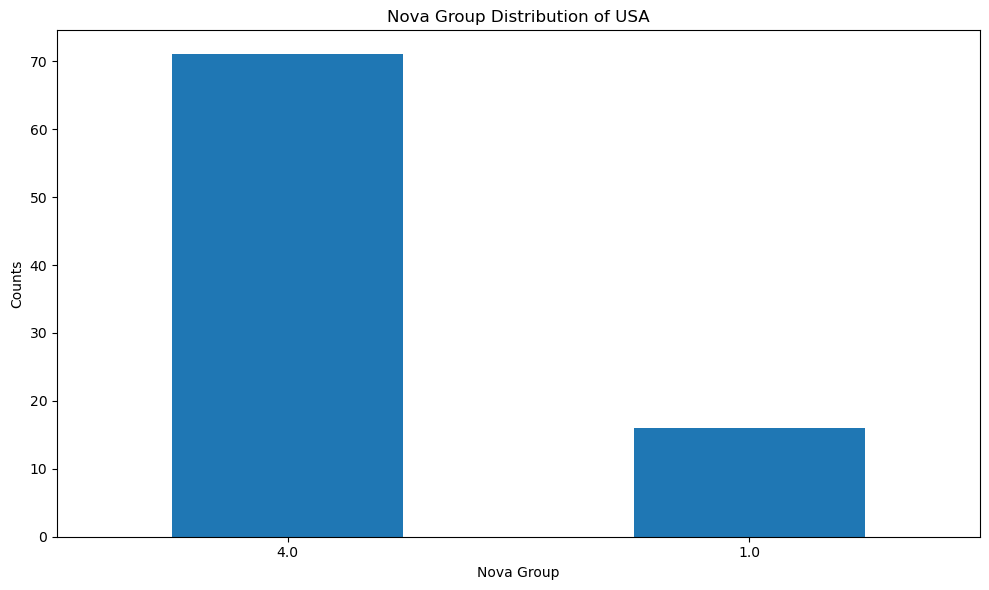

In [61]:
nvcounts = usappp.nova_group.value_counts()

plt.figure(figsize=(10,6))
nvcounts.plot(kind='bar')
plt.title('Nova Group Distribution of USA')
plt.xlabel('Nova Group')
plt.ylabel('Counts')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

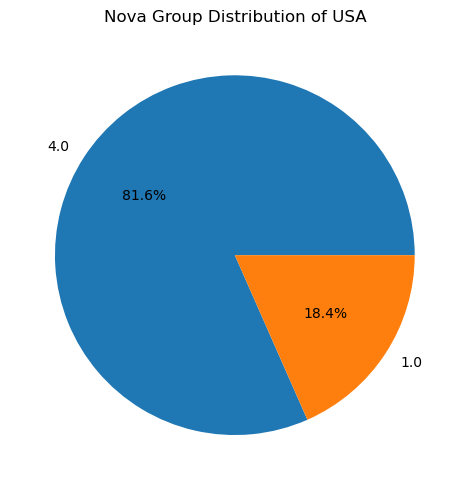

In [62]:
plt.figure(figsize=(5,5))
nvcounts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Nova Group Distribution of USA')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [63]:
usas = usa.copy()

# Suger per 100g 

## Insights

Strong Right-Skewed Distribution: The majority of products are heavily concentrated at the lower end, with nearly 230 items having under 12g of sugar per 100g (led by the first bin at ~157 items).

Moderate Mid-Range Taper: Products with sugar levels between 15g and 65g per 100g appear at low, relatively steady frequencies (mostly below 15 items per bin).

Sparse High-Sugar Range: The 65g–90g range is virtually empty, indicating few products occupy this intermediate high-sugar zone.

Extreme Outliers: A few rare items extend into the extreme high-sugar territory above 90g, reaching up to nearly 130g per 100g (likely pure syrups, honey, concentrates, or reporting anomalies).

In [64]:
usas.sugars_100g.value_counts()

sugars_100g
0.000000     64
10.000000    11
1.840000      7
1.270000      7
3.720000      5
             ..
2.480000      1
2.930000      1
1.740000      1
2.780000      1
10.416667     1
Name: count, Length: 125, dtype: int64

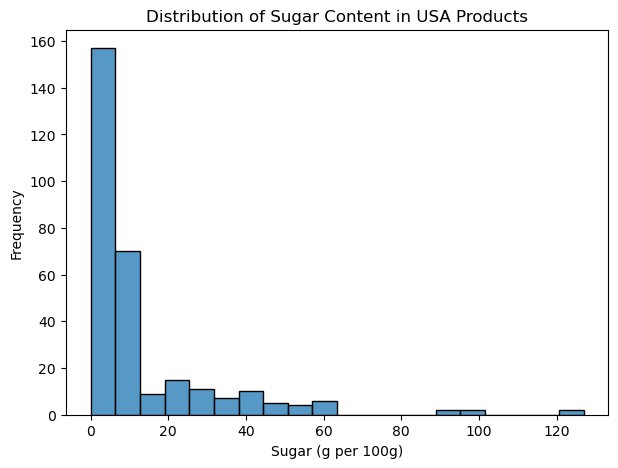

In [65]:
plt.figure(figsize=(7,5))
sns.histplot(data=usas, x='sugars_100g', bins=20)

plt.title('Distribution of Sugar Content in USA Products')
plt.xlabel('Sugar (g per 100g)')
plt.ylabel('Frequency')
plt.show()

# Energy / Calories in USA Products

## Insights

Heavy Low-Calorie Concentration: The distribution is strongly right-skewed, with the vast majority of items clustering under 50 kcal per 100g (~153 products in the 0–25 kcal bin and ~75 products in the 25–50 kcal bin).

Secondary Mid-Range Cluster: A smaller, relatively flat cluster appears between 80 and 260 kcal per 100g, typically averaging 5–15 products per bin.

Caloric Gap: Almost no products fall in the 260 to 370 kcal per 100g range, dividing standard food/beverage items from highly dense products.

High-Calorie Outliers: A few extreme outliers appear between 370 and 520 kcal per 100g, representing energy-dense items like fats, oils, chocolates, or nuts.

In [66]:
usass = usa.copy()
usass.energy_kcal_100g.value_counts()

energy_kcal_100g
0.000000      22
45.833333      7
7.990000       5
148.000000     5
0.676000       5
              ..
23.529412      1
28.169014      1
6.521739       1
50.732807      1
15.200000      1
Name: count, Length: 145, dtype: int64

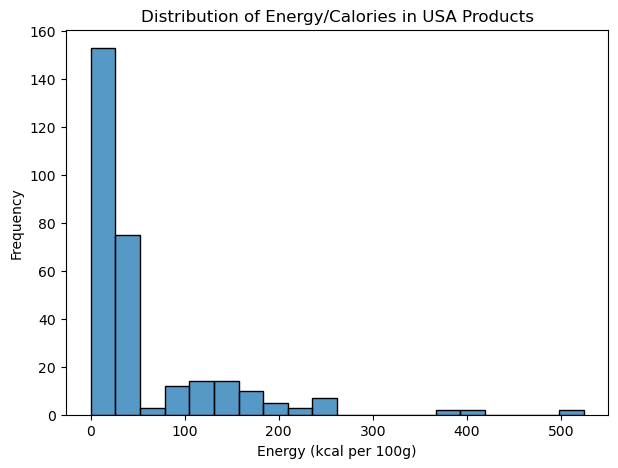

In [67]:

plt.figure(figsize=(7, 5))
sns.histplot(data=usass, x='energy_kcal_100g', bins=20)

plt.title('Distribution of Energy/Calories in USA Products')
plt.xlabel('Energy (kcal per 100g)')
plt.ylabel('Frequency')
plt.show()

# CANADA Analysis

In [68]:
canada = df[df['countries_tags'].str.contains("canada")]
canada

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,sugars_100g,energy_kcal_100g
10,0059600061904,Limonade,Minute Maid,unknown,"canada, france",unknown,unknown,unknown,unknown,4.0,unknown,"Filtered water, Lemon juice from concentrate, ...",NaN,NaN
12,0059600070159,Five Alve,"Minute Maid, Coca-Cola",unknown,canada,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
13,0059600070241,"Jus D'orange (original, Faible En Pulpe)",Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","canada, france",unknown,unknown,unknown,e,1.0,unknown,"EAU FILTRÉE, JUS D'ORANGE CONCENTRÉ.",NaN,NaN
19,05965930,Orange Juice,Minute Maid,unknown,canada,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
109,0059600048097,100% Apple Juice from Concentrate with Added V...,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...",canada,unknown,Dollarama,"Calgary,Alberta,Canada",e,1.0,unknown,"Filtered water, Concentrated apple juice, Asco...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440,0059600070076,minute maid,orange,"plant-based-foods-and-beverages, plant-based-f...",canada,orange,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
450,0005960000042,Fruitopia® Strawberry Passion Awareness 1.75 L,"Fruitopia,minute maid","plant-based-foods-and-beverages, beverages, pl...",canada,"plastic, cardboard",Maxi,Quebec Canada,e,4.0,unknown,"Filtered Water, Fruit Juices from concentrate ...",NaN,NaN
646,4710018316609,peach flavour sidra,minute maid,unknown,canada,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
665,0059600038579,Orange Juice Zero Sugar,Minute Maid,unknown,canada,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN


# Canada Packaging tags Distribution

In [69]:
canadaa = canada.copy()

In [70]:
canadaa.packaging_tags.value_counts()

packaging_tags
unknown                                                62
multilayer-composite, tetra-pak, tetra-brik-aseptic     3
can, drink-can                                          1
orange                                                  1
plastic, cardboard                                      1
Name: count, dtype: int64

In [71]:
canadaa = canada[canada.packaging_tags != 'unknown']
canadaa.packaging_tags.value_counts()

packaging_tags
multilayer-composite, tetra-pak, tetra-brik-aseptic    3
can, drink-can                                         1
orange                                                 1
plastic, cardboard                                     1
Name: count, dtype: int64

In [72]:
canadaa['packaging_tags'] = canadaa['packaging_tags'].str.split(',') 
canadaa = canadaa.explode("packaging_tags")
canadaa['packaging_tags'] = canadaa['packaging_tags'].str.strip() #remove starting void space
canadaa.packaging_tags.value_counts()

/var/folders/yl/hk9fn44n77z9wccr10rvnpjh0000gn/T/ipykernel_1505/455678782.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  canadaa['packaging_tags'] = canadaa['packaging_tags'].str.split(',')


packaging_tags
multilayer-composite    3
tetra-pak               3
tetra-brik-aseptic      3
can                     1
drink-can               1
orange                  1
plastic                 1
cardboard               1
Name: count, dtype: int64

In [73]:
tag_mapping = {
    # can
    'drink-can': 'can',
    '1-canette-en-metal-a-recycler': 'can',
    'conserve': 'can',

    # bottle
    'bouteille-verre': 'bottle',
    'bouteille-consignee': 'bottle',
    'bouteille-en-verre': 'bottle',

    # brick
    'brique': 'brick',

    # metal
    'aluminium': 'metal',
    'recyclable-metals': 'metal',

    # tetra-pak
    'tetra-brik': 'tetra-pak',
    'tetra-brik-aseptic': 'tetra-pak',
}

canadaa['packaging_tags'] = canadaa['packaging_tags'].replace(tag_mapping)

canadaa.packaging_tags.value_counts()

packaging_tags
tetra-pak               6
multilayer-composite    3
can                     2
orange                  1
plastic                 1
cardboard               1
Name: count, dtype: int64

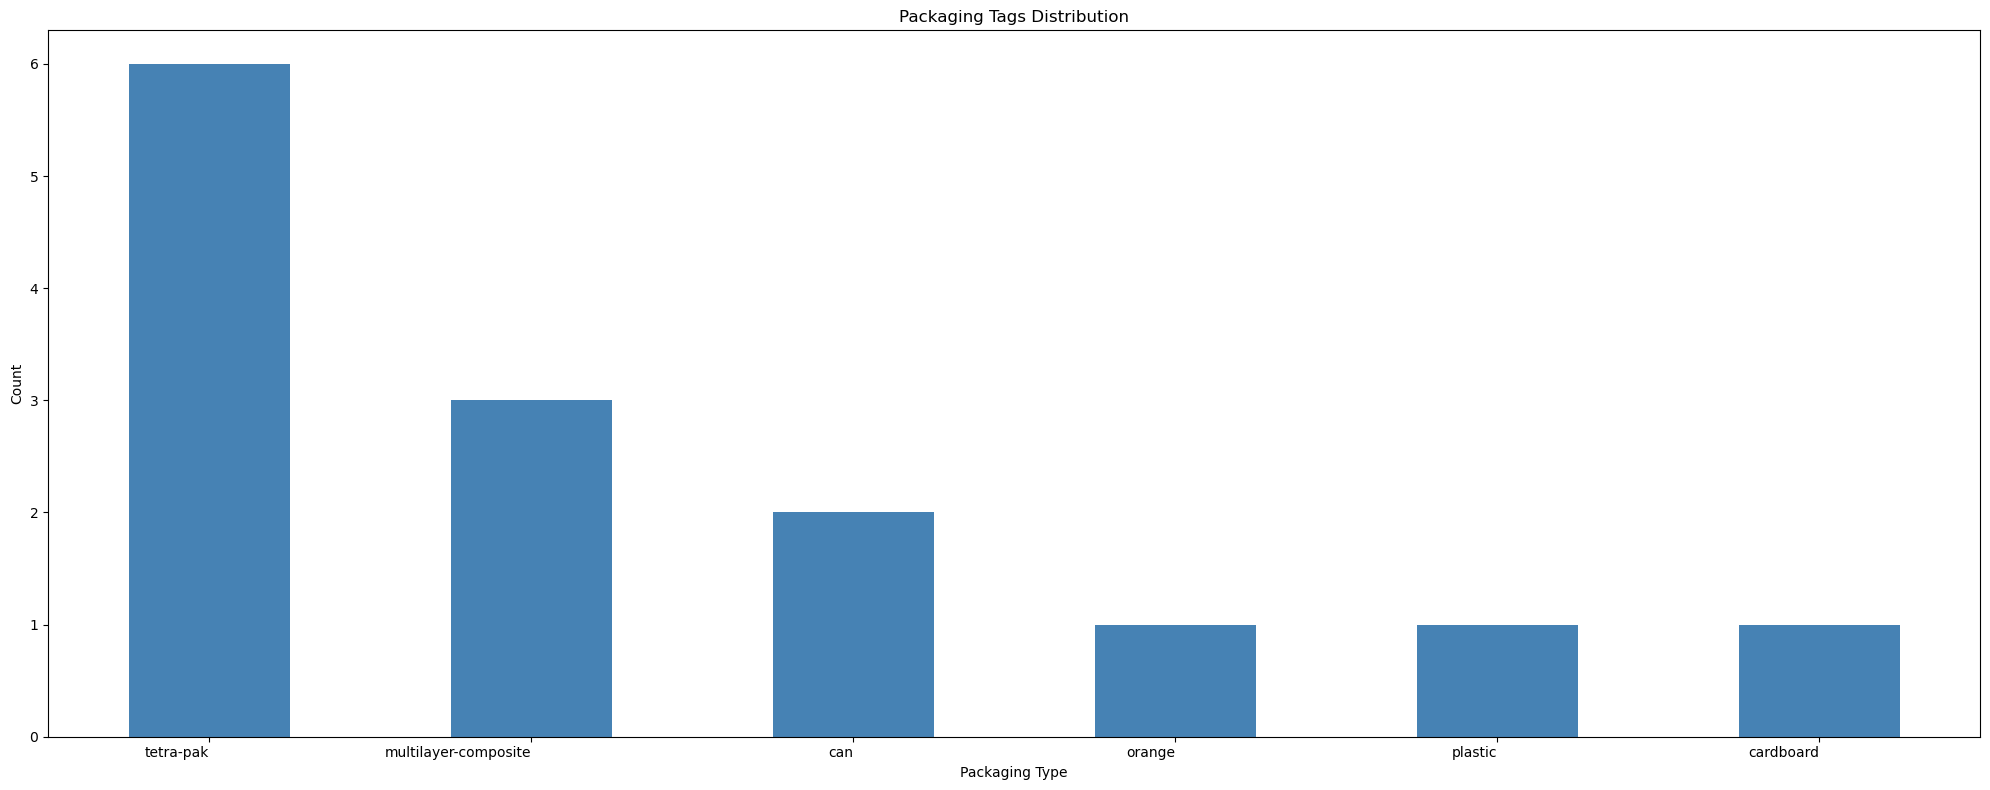

In [74]:
pcounts = canadaa.packaging_tags.value_counts()

plt.figure(figsize=(20, 8))
pcounts.plot(kind='bar', color='steelblue')
plt.title('Packaging Tags Distribution')
plt.xlabel('Packaging Type')
plt.ylabel('Count')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

## Canada Nutriscore Grade Analysis

In [75]:
canadaaa = canada.copy()

In [76]:
canadaaa.nutriscore_grade.value_counts()

nutriscore_grade
unknown    52
e           9
c           4
b           2
d           1
Name: count, dtype: int64

In [77]:
canadaaa = canadaaa[canadaaa.nutriscore_grade != 'unknown']
canadaaa.nutriscore_grade.value_counts()

nutriscore_grade
e    9
c    4
b    2
d    1
Name: count, dtype: int64

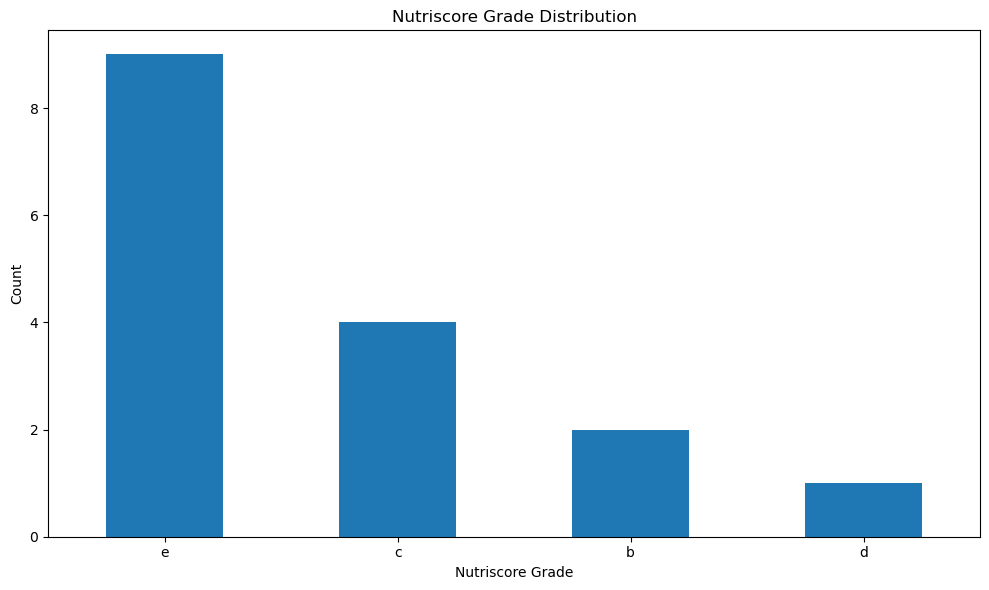

In [78]:
ncounts = canadaaa.nutriscore_grade.value_counts()

plt.figure(figsize=(10, 6))
ncounts.plot(kind='bar')
plt.title('Nutriscore Grade Distribution')
plt.xlabel('Nutriscore Grade')
plt.ylabel('Count')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

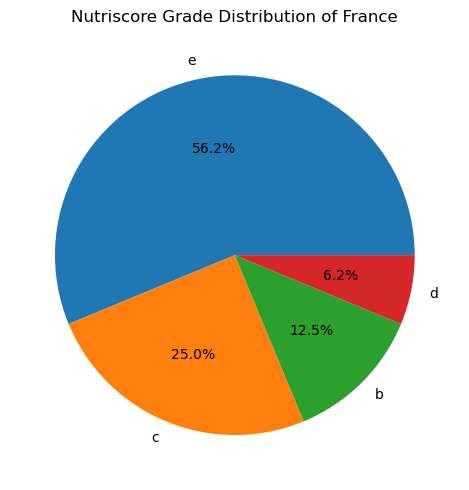

In [79]:
plt.figure(figsize=(5,5))
ncounts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Nutriscore Grade Distribution of France')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Canada Nova Group Analysis

In [80]:
canadaaaa = canada.copy()

In [81]:
canadaaaa.nova_group.value_counts()

nova_group
4.0    13
1.0     6
3.0     1
Name: count, dtype: int64

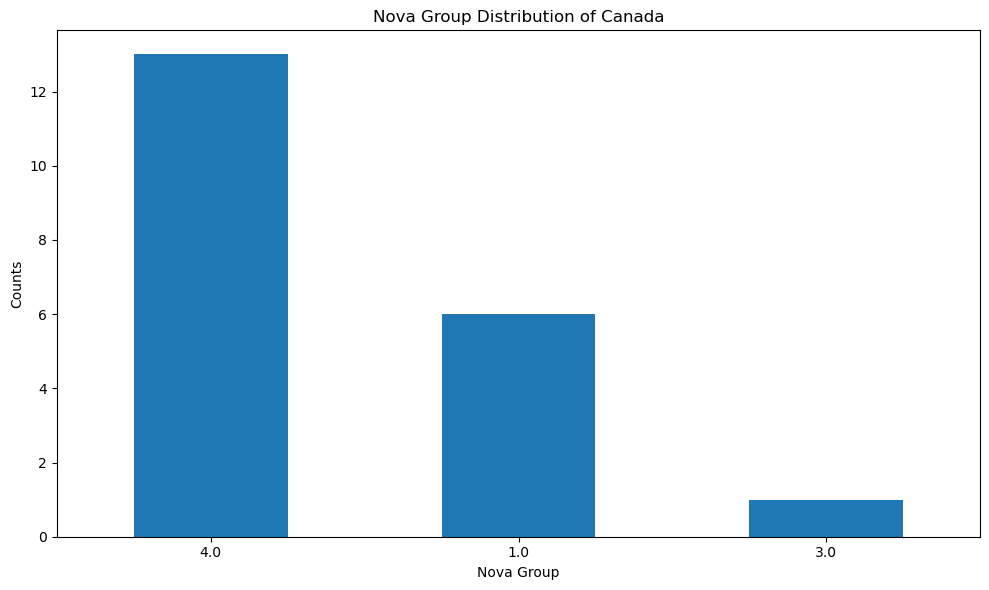

In [82]:
nvcounts = canadaaaa.nova_group.value_counts()

plt.figure(figsize=(10,6))
nvcounts.plot(kind='bar')
plt.title('Nova Group Distribution of Canada')
plt.xlabel('Nova Group')
plt.ylabel('Counts')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

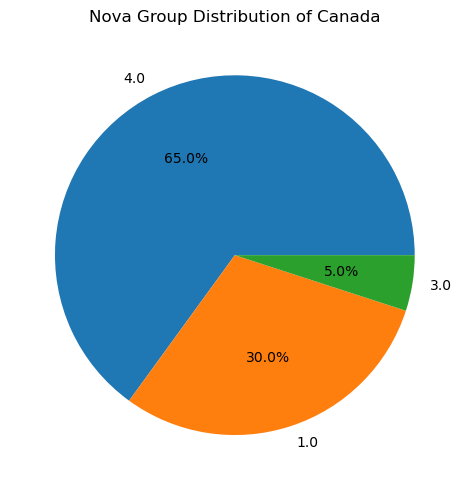

In [83]:
plt.figure(figsize=(5,5))
nvcounts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Nova Group Distribution of Canada')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [84]:
cansugar = canada.copy()
cansugar.sugars_100g.value_counts()

Series([], Name: count, dtype: int64)

# Suger per 100g distribution in CANADA
## There is no data available for specific CANADA country 

In [87]:
calsugar = canada.copy()

In [88]:
calsugar.energy_kcal_100g.value_counts()

Series([], Name: count, dtype: int64)

# Energy / Calaries in CANADA products 
## There is no data available for specific CANADA country

In [1]:
# All the data cleaning and visualization steps have been completed for the USA and Canada datasets. The next steps could involve further analysis, such as comparing the nutritional content between countries, exploring correlations between different nutritional metrics, or building predictive models based on the available data.

# All the data cleaning and visualization steps have been completed for the USA and Canada datasets. The next steps could involve further analysis, such as comparing the nutritional content between countries, exploring correlations between different nutritional metrics, or building predictive models based on the available data.

# Here are Overall Minute maid Insights from this file and another file 

# Packaging 
1. Metadata Completeness Gap: The USA dataset has 97.2% unknown packaging tags, and Canada has 91.2% unknown, while Belgium (51.6% unknown) and France (73.7% unknown) have much higher tag completeness.
2. Packaging Distribution: Where tags are present, France and Belgium are dominated by aluminum cans (26.9% to 37.0%) and bottles, whereas Canada relies heavily on Tetra-Pak cartons and multilayer composites.
# Nutriscore Grade
1. Dominance of Poor Nutritional Scores: Canada (56.2%) and France (45.1%) have their largest single segment concentrated in Grade E (the lowest nutritional score).
2. Polarized Profile in USA: Shows a split distribution with 38.5% at Grade B and 36.1% at Grade E, with very few intermediate items in Grade D (5.7%).
3. Belgium’s Mid-Tier Concentration: Centered heavily at Grade C (53.8%), followed by Grade E (30.8%), with 0.0% recorded in top tiers (Grade A/B).
# Nova Group
1. USA leads in Ultra-Processed Foods: 81.6% of USA evaluated products belong to NOVA Group 4.0, followed by Canada at 65.0%.
2. Europe emphasizes Whole Foods: Belgium reaches 50.0% and France 41.5% in NOVA Group 1.0 (unprocessed or minimally processed foods).
3. Intermediate Processing (NOVA 3.0): Present in minimal proportions across all countries (Canada at 5.0%, France at 3.1%, and 0.0% recorded for USA and Belgium).